# 1. Import Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# 2. Load Raw data

In [97]:
df = pd.read_csv('housing.csv') 

print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
print("Shape:", df.shape)


Raw data loaded!
Rows: 20640 | Columns: 10
Shape: (20640, 10)


# 3. First Look at the Data

In [98]:
#Tells us the number of rows and columns
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [99]:
# Show all column names
print("Column names:")
print(list(df.columns))


Column names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [100]:
print("Data types:")
print(df.dtypes)

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


# 4.Check Missing Values

In [101]:
# Count missing/empty values in every column
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing)

print("\nTotal missing values:", missing.sum())


Missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Total missing values: 207


# 5. Mean, Median, and Mode for Missing Value Columns

In [102]:
missing_columns = df.columns[df.isnull().any()]

print("Columns containing null values:")
print(missing_columns.tolist())

for column in missing_columns:
    print("\nColumn:", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])


Columns containing null values:
['total_bedrooms']

Column: total_bedrooms
Mean: 537.8705525375618
Median: 435.0
Mode: 280.0


# 6. Compare Mean, Median, and Mode

In [103]:
missing_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode(numeric_only=True).iloc[0]
})

print(missing_summary)


                    Null Count           Mean       Median        Mode
households                   0     499.539680     409.0000     306.000
housing_median_age           0      28.639486      29.0000      52.000
latitude                     0      35.631861      34.2600      34.060
longitude                    0    -119.569704    -118.4900    -118.310
median_house_value           0  206855.816909  179700.0000  500001.000
median_income                0       3.870671       3.5348       3.125
ocean_proximity              0            NaN          NaN         NaN
population                   0    1425.476744    1166.0000     891.000
total_bedrooms             207     537.870553     435.0000     280.000
total_rooms                  0    2635.763081    2127.0000    1527.000


# 7. Calculate Duplicate Values in Each Column

In [104]:
print("Duplicate values in EACH column:")
print()

for column in df.columns:
    duplicate_values = df[column].duplicated().sum()
    print(column, ":", duplicate_values)

Duplicate values in EACH column:

longitude : 19796
latitude : 19778
housing_median_age : 20588
total_rooms : 14714
total_bedrooms : 18716
population : 16752
households : 18825
median_income : 7712
median_house_value : 16798
ocean_proximity : 20635


# 8. Number of Unique Values in Each Column

In [105]:
print("Unique values in EACH column:")
print()

for column in df.columns:
    print(column, ":", df[column].nunique())

Unique values in EACH column:

longitude : 844
latitude : 862
housing_median_age : 52
total_rooms : 5926
total_bedrooms : 1923
population : 3888
households : 1815
median_income : 12928
median_house_value : 3842
ocean_proximity : 5


# 9. Duplicate Rows

In [106]:
duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


# 10. Basic Statistical Summary

In [107]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

# 11. Unique Values in Ocean Proximity

In [108]:
print("Unique ocean_proximity values:")
print(df["ocean_proximity"].unique())

print("\nCounts:")
print(df["ocean_proximity"].value_counts())


Unique ocean_proximity values:
['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']

Counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


## 12. Fill Null Values Using the Median

In [109]:
print("Null values before:")
print(df["total_bedrooms"].isnull().sum())

median_value = df["total_bedrooms"].median()

df["total_bedrooms"] = df["total_bedrooms"].fillna(median_value)

print("Median used:", median_value)
print("Null values after:")
print(df["total_bedrooms"].isnull().sum())


Null values before:
207
Median used: 435.0
Null values after:
0


# 13. Final Null Check

In [110]:
print("Null values after cleaning:")
print(df.isnull().sum())

print("\nTotal null values:", df.isnull().sum().sum())


Null values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Total null values: 0


# 14. Remove Completely Duplicated Rows

In [111]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicate rows removed:", before - after)

Rows before: 20640
Rows after: 20640
Duplicate rows removed: 0


## 15. Correlation Heatmap

The heatmap shows the correlation between numerical columns.

- Positive value → variables move in the same direction
- Negative value → variables move in opposite directions
- Near 0 → weak linear relationship

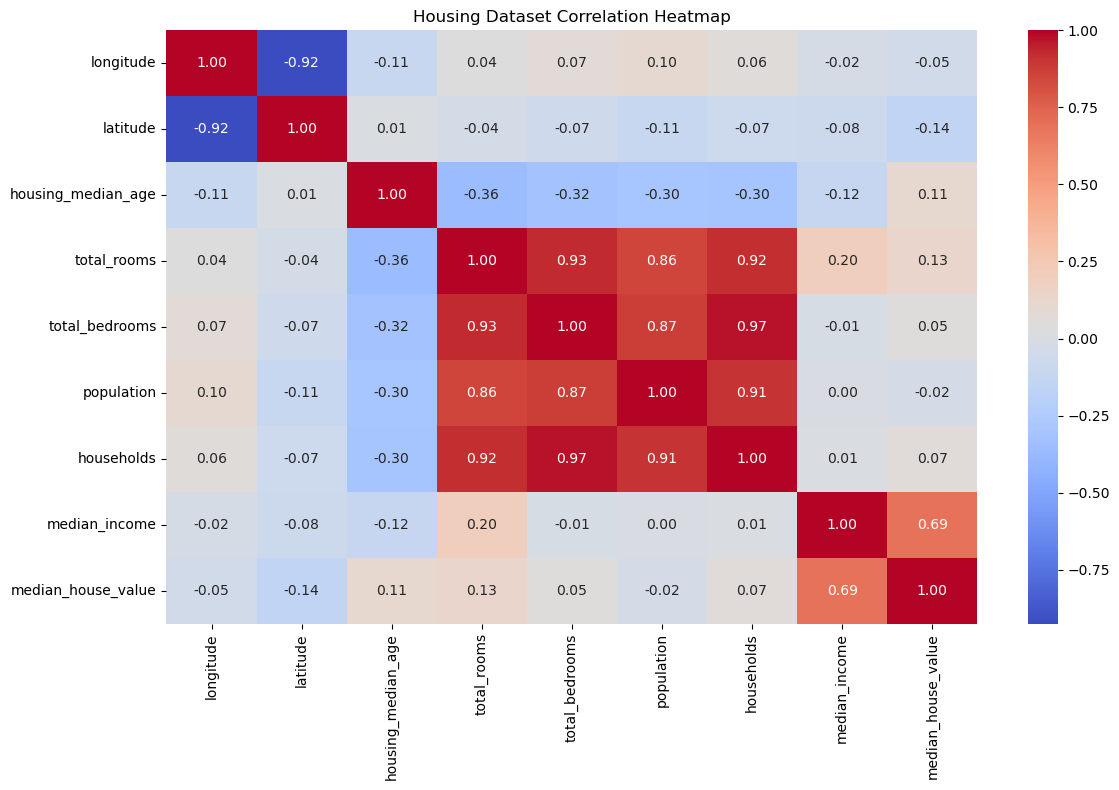

In [112]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Housing Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()

# 16. Correlation With Median House Value

In [113]:
house_value_correlation = correlation["median_house_value"].sort_values(ascending=False)

print("Correlation with median_house_value:")
print(house_value_correlation)

Correlation with median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


# 17. Histogram — Median House Value

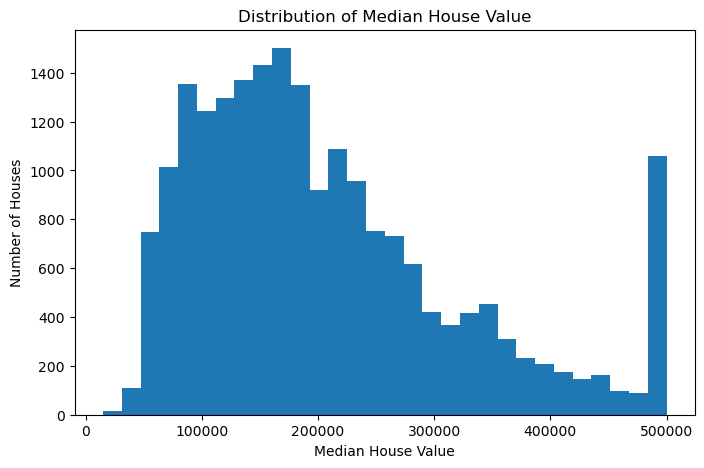

In [114]:
plt.figure(figsize=(8, 5))
plt.hist(df["median_house_value"], bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Number of Houses")
plt.title("Distribution of Median House Value")
plt.show()

# 18. Scatter Plot — Median Income vs Median House Value

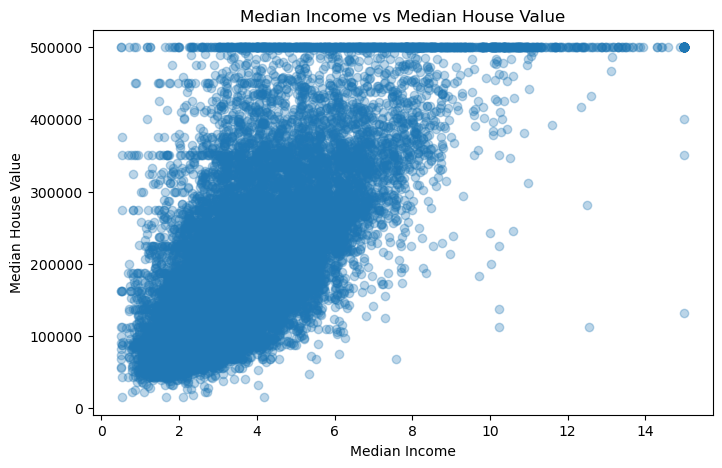

In [115]:
plt.figure(figsize=(8, 5))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()


# 19. Prepare Data for Linear Regression

In [116]:
df_model = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    dtype=int
)

print(df_model.head())
print("\nNew shape:", df_model.shape)


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                          0                       0                       0   
1   

# 20. Single-Feature Linear Regression

Feature: `median_income`

Target: `median_house_value`

In [117]:
X = df_model[["median_income"]]
y = df_model["median_house_value"]

print("Feature:", X.columns.tolist())
print("Target:", y.name)

Feature: ['median_income']
Target: median_house_value


# 21. Split Data — 70% Training / 30% Testing

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 14448
Testing rows: 6192


# 22. Train Single-Feature Linear Regression

In [119]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Model trained successfully!
Slope: 41819.326975983764
Intercept: 44794.96555604329


# 23. Predict and Evaluate

In [120]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE: 62315.59
RMSE: 83174.39
R² Score: 0.4729


# 24. Multi-Feature Linear Regression

Features:
- longitude
- latitude
- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income

Target: `median_house_value`


In [121]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_multi = df_model[features]

print("Features:")
print(features)


Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


# 25. Split Multi-Feature Data — 70% / 30%
- **70% training data** = used to teach the model
- **30% testing data** = used to check how well the model works on unseen data

In [122]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", len(X_train_multi))
print("Testing rows:", len(X_test_multi))

Training rows: 14448
Testing rows: 6192


# 26. Train Multi-Feature Model

In [123]:
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

print("Multi-feature model trained successfully!")

Multi-feature model trained successfully!


# 27. Evaluate Multi-Feature Model

In [124]:
y_pred_multi = model_multi.predict(X_test_multi)

mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("MAE:", round(mae_multi, 2))
print("RMSE:", round(rmse_multi, 2))
print("R² Score:", round(r2_multi, 4))

MAE: 51048.95
RMSE: 69692.01
R² Score: 0.63


# 28. Compare the Models

In [125]:
comparison = pd.DataFrame({
    "Model": ["Single Feature", "Multi Feature"],
    "Features": ["median_income", "8 housing features"],
    "Train": ["70%", "70%"],
    "Test": ["30%", "30%"],
    "R2 Score": [r2, r2_multi],
    "MAE": [mae, mae_multi],
    "RMSE": [rmse, rmse_multi]
})

print(comparison)

            Model            Features Train Test  R2 Score           MAE  \
0  Single Feature       median_income   70%  30%  0.472932  62315.592938   
1   Multi Feature  8 housing features   70%  30%  0.629956  51048.951982   

           RMSE  
0  83174.394305  
1  69692.013573  


# 29. Best Model

In [126]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("R² Score:", round(best_model["R2 Score"], 4))
print("MAE:", round(best_model["MAE"], 2))
print("RMSE:", round(best_model["RMSE"], 2))

Best Model: Multi Feature
R² Score: 0.63
MAE: 51048.95
RMSE: 69692.01


# Final Summary

### Data Cleaning
- Checked null values in each column.
- Calculated **mean, median, and mode** for columns containing null values.
- Filled `total_bedrooms` null values using its median.
- Calculated duplicate values in **each column**.
- Checked completely duplicated rows.
- Checked unique values.

### Data Analysis
- Created a **correlation heatmap**.
- Checked correlation with `median_house_value`.
- Created histogram and scatter plot.

### Machine Learning
- Used Linear Regression.
- Used 70% training and 30% testing.
- Tested a single-feature model and a multi-feature model.
- Calculated R², MAE, and RMSE.